In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Display all the columns of the dataframe
# pd.pandas.set_option('display.max_columns',None)

In [29]:
df = pd.read_csv("dataset\steam_top_games_2026.csv")
df.head(5)


<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
C:\Users\HP\AppData\Local\Temp\ipykernel_18140\1903245458.py:1: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv("dataset\steam_top_games_2026.csv")


,app_id,name,release_date,coming_soon,price_usd,is_free,discount_pct,developer,publisher,genres,...,estimated_owners,avg_playtime_forever,avg_playtime_2weeks,median_playtime,peak_ccu,required_age,dlc_count,achievements,short_description,header_image
0,794260,Outward Definitive Edition,"May 17, 2022",False,4.79,False,88,Nine Dots Studio,"Prime Matter, Deep Silver",RPG,...,"1,000,000 .. 2,000,000",1332,824,465,469,0,1,72,No remarkable journey is achieved without grea...,https://shared.akamai.steamstatic.com/store_it...
1,253920,Gorky 17,"Sep 27, 2013",False,9.99,False,0,Metropolis Software,TopWare Interactive,"RPG, Strategy",...,"200,000 .. 500,000",301,0,328,61,17,2,0,November 2008. NATO intelligence services repo...,https://shared.akamai.steamstatic.com/store_it...
2,613010,Secret in Story,"Jun 19, 2017",False,0.89,False,10,Naivus Luo,Naivus Luo,"Adventure, Indie",...,"2,000,000 .. 5,000,000",251,0,243,0,0,0,32,"Accompanied by beautiful piano music, you begi...",https://shared.akamai.steamstatic.com/store_it...
3,892420,懒人修仙传,"Nov 14, 2018",False,3.99,False,0,托更的修罗,托更的修罗,"Casual, Indie, RPG, Simulation",...,"200,000 .. 500,000",5786,0,9223,41,0,0,0,这是一款很&quot;休闲&quot;的文字挂机游戏，游戏小而系统完善，玩法丰富，极其耗电，...,https://shared.akamai.steamstatic.com/store_it...
4,914010,Train Station Renovation,"Oct 1, 2020",False,18.99,False,0,Live Motion Games,"Live Motion Games, Frozen Way, PlayWay S.A., F...","Casual, Indie, Simulation",...,"200,000 .. 500,000",448,0,201,16,0,1,73,"Welcome to an old, ruined train station. A pla...",https://shared.akamai.steamstatic.com/store_it...


## Handling Missing Values

In [30]:
# cek nilai kosong
df.isnull().sum()

app_id                    0
name                      0
release_date              7
coming_soon               0
price_usd                 0
is_free                   0
discount_pct              0
developer                 8
publisher                12
genres                    8
categories                9
tags                      6
platforms_win             0
platforms_mac             0
platforms_linux           0
metacritic_score        955
recommendations           0
positive_reviews          0
negative_reviews          0
estimated_owners          5
avg_playtime_forever      0
avg_playtime_2weeks       0
median_playtime           0
peak_ccu                  0
required_age              0
dlc_count                 0
achievements              0
short_description         2
header_image              1
dtype: int64

In [31]:
## Hapus baris atau titik data untuk menangani nilai yang hilang
# menghitung baris sebelum dihapus
df.shape

(1495, 29)

In [32]:
# menghitung baris setelah dihapus
df.dropna().shape

(525, 29)

In [33]:
## Menghapus perkolom
df.dropna(axis=1)

,app_id,name,coming_soon,price_usd,is_free,discount_pct,platforms_win,platforms_mac,platforms_linux,recommendations,positive_reviews,negative_reviews,avg_playtime_forever,avg_playtime_2weeks,median_playtime,peak_ccu,required_age,dlc_count,achievements
0,794260,Outward Definitive Edition,False,4.79,False,88,True,False,False,23986,20738,7717,1332,824,465,469,0,1,72
1,253920,Gorky 17,False,9.99,False,0,True,True,True,909,1616,411,301,0,328,61,17,2,0
2,613010,Secret in Story,False,0.89,False,10,True,True,False,0,79,35,251,0,243,0,0,0,32
3,892420,懒人修仙传,False,3.99,False,0,True,False,False,1169,769,509,5786,0,9223,41,0,0,0
4,914010,Train Station Renovation,False,18.99,False,0,True,False,False,1948,2154,466,448,0,201,16,0,1,73
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1490,1590910,Forgive Me Father,False,19.99,False,0,True,False,False,3350,4083,742,204,0,106,61,0,1,20
1491,1693970,PARTY RUSH!!,False,9.99,False,0,True,False,False,0,12,6,0,0,0,0,0,1,15
1492,1225330,NBA 2K21,False,0.00,False,0,True,False,False,28213,16233,22823,6563,0,4090,148,0,0,50
1493,764030,Realm Revolutions,False,0.00,True,0,True,False,False,0,273,95,20080,0,4114,57,0,0,0



## Imputasi Nilai yang Hilang

<Axes: xlabel='metacritic_score', ylabel='Count'>

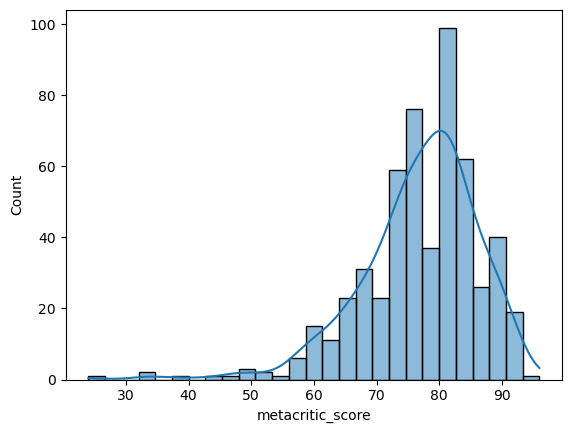

In [ ]:
## Handle kolom metacritic_score  
sns.histplot(df['metacritic_score'],kde=True)


In [ ]:
# mencari dan mengisi nilai median untuk kolom metacritic_score
df['metacritic_score_median']=df['metacritic_score'].fillna(df['metacritic_score'].median())
df['metacritic_score_median']

0       78.0
1       78.0
2       78.0
3       78.0
4       68.0
        ... 
1490    74.0
1491    78.0
1492    78.0
1493    78.0
1494    78.0
Name: metacritic_score_median, Length: 1495, dtype: float64

In [44]:
df[['metacritic_score','metacritic_score_median']]

,metacritic_score,metacritic_score_median
0,NaN,78.0
1,NaN,78.0
2,NaN,78.0
3,NaN,78.0
4,68.0,68.0
...,...,...
1490,74.0,74.0
1491,NaN,78.0
1492,NaN,78.0
1493,NaN,78.0


In [ ]:
## Handle kolom release_date
#melihat jumlah data kosong
df[df['release_date'].isnull()]

,app_id,name,release_date,coming_soon,price_usd,is_free,discount_pct,developer,publisher,genres,...,avg_playtime_2weeks,median_playtime,peak_ccu,required_age,dlc_count,achievements,short_description,header_image,metacritic_score_median,release_date_mode
122,63380,Sniper Elite V2,NaN,False,0.00,False,0,Rebellion,Rebellion,Action,...,0,194,34,0,4,47,In the dark days of the end of World War Two a...,https://shared.akamai.steamstatic.com/store_it...,66.0,"Apr 25, 2017"
615,223850,3DMark,NaN,False,34.99,False,0,UL Solutions,UL Solutions,Utilities,...,454,246,699,0,21,29,"3DMark is for gamers, overclockers and system ...",https://shared.akamai.steamstatic.com/store_it...,78.0,"Apr 25, 2017"
652,214560,Mark of the Ninja,NaN,False,0.00,False,0,Klei Entertainment,Microsoft Studios,"Action, Adventure, Indie",...,0,201,2,17,0,38,"In Mark of the Ninja, you'll know what it is t...",https://shared.akamai.steamstatic.com/store_it...,91.0,"Apr 25, 2017"
719,224540,Ace of Spades: Battle Builder,NaN,False,0.00,False,0,Jagex Limited,Jagex Limited,"Action, Indie",...,0,264,0,0,0,77,Say hello to the creative shooter. Ace of Spad...,https://shared.akamai.steamstatic.com/store_it...,49.0,"Apr 25, 2017"
786,577800,NBA 2K18,NaN,False,0.00,False,0,Visual Concepts,2K,"Simulation, Sports",...,0,4694,58,0,0,50,The highest rated* annual sports title returns...,https://shared.akamai.steamstatic.com/store_it...,87.0,"Apr 25, 2017"
842,44340,Operation Flashpoint: Red River,NaN,False,0.00,False,0,Codemasters Action Studio,Codemasters,"Action, Strategy",...,0,49,1,17,0,0,Stand together with the US Marines in Operatio...,https://shared.akamai.steamstatic.com/store_it...,67.0,"Apr 25, 2017"
1344,202170,Sleeping Dogs,NaN,False,0.00,False,0,United Front Games,Square Enix,"Action, Adventure",...,0,560,18,17,25,59,"As Wei Shen, an undercover cop trying to take ...",https://shared.akamai.steamstatic.com/store_it...,80.0,"Apr 25, 2017"


In [54]:
# mencari nilai uniq
df['release_date'].unique()

array(['May 17, 2022', 'Sep 27, 2013', 'Jun 19, 2017', ...,
       'Nov 14, 2014', 'Apr 7, 2022', 'Jan 5, 2018'],
      shape=(1187,), dtype=object)

In [60]:
# mencari dan mengisi nilai modus untuk kolom release_date
df['release_date_mode'] = df[df['release_date'].notna()]['release_date'].mode()[0]

In [97]:
#  melihat nilai null dan mode
df[df[['release_date_mode', 'release_date']].isnull().any(axis=1)].head(5)


,app_id,name,release_date,coming_soon,price_usd,is_free,discount_pct,developer,publisher,genres,...,median_playtime,peak_ccu,required_age,dlc_count,achievements,short_description,header_image,metacritic_score_median,release_date_mode,publisher_mode
122,63380,Sniper Elite V2,NaN,False,0.00,False,0,Rebellion,Rebellion,Action,...,194,34,0,4,47,In the dark days of the end of World War Two a...,https://shared.akamai.steamstatic.com/store_it...,66.0,"Apr 25, 2017",Ubisoft
615,223850,3DMark,NaN,False,34.99,False,0,UL Solutions,UL Solutions,Utilities,...,246,699,0,21,29,"3DMark is for gamers, overclockers and system ...",https://shared.akamai.steamstatic.com/store_it...,78.0,"Apr 25, 2017",Ubisoft
652,214560,Mark of the Ninja,NaN,False,0.00,False,0,Klei Entertainment,Microsoft Studios,"Action, Adventure, Indie",...,201,2,17,0,38,"In Mark of the Ninja, you'll know what it is t...",https://shared.akamai.steamstatic.com/store_it...,91.0,"Apr 25, 2017",Ubisoft
719,224540,Ace of Spades: Battle Builder,NaN,False,0.00,False,0,Jagex Limited,Jagex Limited,"Action, Indie",...,264,0,0,0,77,Say hello to the creative shooter. Ace of Spad...,https://shared.akamai.steamstatic.com/store_it...,49.0,"Apr 25, 2017",Ubisoft
786,577800,NBA 2K18,NaN,False,0.00,False,0,Visual Concepts,2K,"Simulation, Sports",...,4694,58,0,0,50,The highest rated* annual sports title returns...,https://shared.akamai.steamstatic.com/store_it...,87.0,"Apr 25, 2017",Ubisoft


In [71]:
#cek  apakah nilai masin null
df['release_date_mode'].isnull().sum()

np.int64(0)

In [73]:
df['release_date'].isnull().sum()

np.int64(7)

In [96]:
## mengandle kolom publisher
#melihat jumlah data kosong
df[df['publisher'].isnull()].head(5)


,app_id,name,release_date,coming_soon,price_usd,is_free,discount_pct,developer,publisher,genres,...,median_playtime,peak_ccu,required_age,dlc_count,achievements,short_description,header_image,metacritic_score_median,release_date_mode,publisher_mode
87,945490,Little Square Things,"Sep 28, 2019",False,0.00,True,0,G.Reed,NaN,"Indie, Strategy",...,0,0,0,2,28,Forget the box. Think outside the entire wareh...,https://shared.akamai.steamstatic.com/store_it...,78.0,"Apr 25, 2017",Ubisoft
109,783140,Removed,"Apr 13, 2018",False,0.00,False,0,NaN,NaN,"Action, Indie, Simulation",...,31,0,0,0,0,NaN,NaN,78.0,"Apr 25, 2017",Ubisoft
186,736590,Operation: Harsh Doorstop,"Feb 15, 2023",False,0.00,True,0,Drakeling Labs,NaN,"Action, Casual, Indie, Simulation, Strategy, F...",...,41,119,0,6,0,"Operation: Harsh Doorstop is the ultimate, fre...",https://shared.akamai.steamstatic.com/store_it...,78.0,"Apr 25, 2017",Ubisoft
319,13250,Unreal Gold,"Mar 17, 2008",False,0.00,False,0,"Epic Games, Inc.",NaN,Action,...,13,3,0,0,0,Your prison ship has crash-landed on the faste...,https://shared.akamai.steamstatic.com/store_it...,78.0,"Apr 25, 2017",Ubisoft
432,208730,Game of Thrones,"Jun 7, 2012",False,14.99,False,0,Cyanide Studios,NaN,"Action, RPG",...,77,2,0,3,50,Experience an amazing adventure in one of the ...,https://shared.akamai.steamstatic.com/store_it...,58.0,"Apr 25, 2017",Ubisoft


In [94]:
# mencari nilai uniq
df['publisher'].unique()[0:10]

array(['Prime Matter, Deep Silver', 'TopWare Interactive', 'Naivus Luo',
       '托更的修罗',
       'Live Motion Games, Frozen Way, PlayWay S.A., Frozen District',
       'Kalypso Media Digital', 'Vertigo Gaming Inc.',
       'Topware Interactive', 'David Szymanski', 'Ubisoft'], dtype=object)

In [79]:
df['publisher_mode'] = df[df['publisher'].notna()]['publisher'].mode()[0]
df['publisher_mode']

0       Ubisoft
1       Ubisoft
2       Ubisoft
3       Ubisoft
4       Ubisoft
         ...   
1490    Ubisoft
1491    Ubisoft
1492    Ubisoft
1493    Ubisoft
1494    Ubisoft
Name: publisher_mode, Length: 1495, dtype: object

In [95]:
df[df[['publisher_mode', 'publisher']].isnull().any(axis=1)].head(5)

,app_id,name,release_date,coming_soon,price_usd,is_free,discount_pct,developer,publisher,genres,...,median_playtime,peak_ccu,required_age,dlc_count,achievements,short_description,header_image,metacritic_score_median,release_date_mode,publisher_mode
87,945490,Little Square Things,"Sep 28, 2019",False,0.00,True,0,G.Reed,NaN,"Indie, Strategy",...,0,0,0,2,28,Forget the box. Think outside the entire wareh...,https://shared.akamai.steamstatic.com/store_it...,78.0,"Apr 25, 2017",Ubisoft
109,783140,Removed,"Apr 13, 2018",False,0.00,False,0,NaN,NaN,"Action, Indie, Simulation",...,31,0,0,0,0,NaN,NaN,78.0,"Apr 25, 2017",Ubisoft
186,736590,Operation: Harsh Doorstop,"Feb 15, 2023",False,0.00,True,0,Drakeling Labs,NaN,"Action, Casual, Indie, Simulation, Strategy, F...",...,41,119,0,6,0,"Operation: Harsh Doorstop is the ultimate, fre...",https://shared.akamai.steamstatic.com/store_it...,78.0,"Apr 25, 2017",Ubisoft
319,13250,Unreal Gold,"Mar 17, 2008",False,0.00,False,0,"Epic Games, Inc.",NaN,Action,...,13,3,0,0,0,Your prison ship has crash-landed on the faste...,https://shared.akamai.steamstatic.com/store_it...,78.0,"Apr 25, 2017",Ubisoft
432,208730,Game of Thrones,"Jun 7, 2012",False,14.99,False,0,Cyanide Studios,NaN,"Action, RPG",...,77,2,0,3,50,Experience an amazing adventure in one of the ...,https://shared.akamai.steamstatic.com/store_it...,58.0,"Apr 25, 2017",Ubisoft


In [82]:
#cek  apakah nilai masin null
df['publisher_mode'].isnull().sum()


np.int64(0)

In [98]:
df['publisher'].isnull().sum()

np.int64(12)

In [99]:
## Handle kolom short_description,header_image,estimated_owners

df[['short_description','header_image','estimated_owners']].dropna()

,short_description,header_image,estimated_owners
0,No remarkable journey is achieved without grea...,https://shared.akamai.steamstatic.com/store_it...,"1,000,000 .. 2,000,000"
1,November 2008. NATO intelligence services repo...,https://shared.akamai.steamstatic.com/store_it...,"200,000 .. 500,000"
2,"Accompanied by beautiful piano music, you begi...",https://shared.akamai.steamstatic.com/store_it...,"2,000,000 .. 5,000,000"
3,这是一款很&quot;休闲&quot;的文字挂机游戏，游戏小而系统完善，玩法丰富，极其耗电，...,https://shared.akamai.steamstatic.com/store_it...,"200,000 .. 500,000"
4,"Welcome to an old, ruined train station. A pla...",https://shared.akamai.steamstatic.com/store_it...,"200,000 .. 500,000"
...,...,...,...
1490,Forgive Me Father is a dark retro horror FPS s...,https://shared.akamai.steamstatic.com/store_it...,"500,000 .. 1,000,000"
1491,"Here we present, a cynical RPG with close to 1...",https://shared.akamai.steamstatic.com/store_it...,"200,000 .. 500,000"
1492,NOTE: All multiplayer servers for NBA 2K21 wil...,https://shared.akamai.steamstatic.com/store_it...,"1,000,000 .. 2,000,000"
1493,Earning coins and resources is more fun than e...,https://shared.akamai.steamstatic.com/store_it...,"200,000 .. 500,000"
